# Phonon Dispersion
## Introduction
In this example, we use harmonic lattice dynamics to calculate the phonon dispersion of diamond silicon using a Tersoff potential. If you use a NEP model, we recommend you try the [calorine](https://calorine.materialsmodeling.org/) package. It may make your life easier by significantly simplifying the process.

### Importing Relevant Functions
The inputs/outputs for GPUMD are processed using the [Atomic Simulation Environment (ASE)](https://wiki.fysik.dtu.dk/ase/) package.

In [1]:
from pylab import *
from ase.build import bulk
from ase.io import write

## Preparting the Inputs
The structure as specified is 2-atom unitcell diamond silicon at zero temperature and zero pressure. 
We use the minimal Tersoff potential [[Fan 2020]](https://doi.org/10.1088/1361-648X/ab5c5f).

### Generate the  [model.xyz](https://gpumd.org/gpumd/input_files/model_xyz.html) file:

### Create Si Unit Cell (only unit cell)

In [2]:
a=5.434
Si_UC = bulk('Si', 'diamond', a=a)
Si_UC

Atoms(symbols='Si2', pbc=True, cell=[[0.0, 2.717, 2.717], [2.717, 0.0, 2.717], [2.717, 2.717, 0.0]])

### Write [model.xyz](https://gpumd.org/gpumd/input_files/model_xyz.html) File

In [3]:
write("model.xyz", Si_UC)

### Write [kpoints.in](https://gpumd.org/gpumd/input_files/kpoints_in.html) File
- The $k$ vectors are defined in the reciprocal space with respect to the [model.xyz](https://gpumd.org/gpumd/input_files/model_xyz.html) file.
- We use the $\Gamma-X-K-\Gamma-L$ path.

In [4]:
kpoints = ['GXKGL']
with open('kpoints.in', 'w') as f:
    for kp in kpoints:
        path = Si_UC.cell.bandpath(path=kp, npoints=0)
        for label in kp:
            k = path.special_points[label]
            f.write(f"{k[0]:.3f} {k[1]:.3f} {k[2]:.3f} {label}\n")
        f.write("\n")

```
0.000 0.000 0.000 G
0.500 0.000 0.500 X
0.375 0.375 0.750 K
0.000 0.000 0.000 G
0.500 0.500 0.500 L
```

## The `run.in` file:
The [run.in input file](https://gpumd.org/gpumd/input_files/run_in.html) is given below:<br>
```
replicate       8 8 8
potential       ../../../potentials/tersoff/Si_Fan_2019.txt
compute_phonon  0.005 # in units of A
```

- The first line with the [replicate](https://gpumd.org/gpumd/input_parameters/replicate.html) keyword states that the system will be replicated by 8 in each direction.

- The second line with the [potential](https://gpumd.org/gpumd/input_parameters/potential.html) keyword states that the potential to be used is specified in the file [Si_Fan_2019.txt](https://github.com/brucefan1983/GPUMD/blob/master/potentials/tersoff/Si_Fan_2019.txt).

- The third line with the [compute_phonon](https://gpumd.org/gpumd/input_parameters/compute_phonon.html) keyword tells will be calculated with  a displacement of 0.005 $\mathring A$ will be used in the finite-displacement method.

## Results and Discussion

### Figure Properties

In [5]:
aw = 2
fs = 24
font = {'size'   : fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes' , linewidth=aw)

def set_fig_properties(ax_list):
    tl = 8
    tw = 2
    tlm = 4
    
    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in', right=True, top=True)

## Plot Phonon Dispersion
The [omega2.out](https://gpumd.org/gpumd/output_files/omega2_out.html) output file is loaded and processed to create the following figure. The previously defined kpoints are used for the $x$-axis.

In [6]:
with open("omega2.out", 'r') as f:
    first_line = f.readline().strip().lstrip('#').split()
    sym_points = first_line[:len(first_line)//2]
    sym_points = [float(x) for x in sym_points]
omega2_array = np.loadtxt("omega2.out")
linear_path = omega2_array[:, 0]
nu = np.sqrt(omega2_array[:, 1:])/(2*np.pi)

/tmp/ipykernel_1034/2968833946.py:7: RuntimeWarning: invalid value encountered in sqrt
  nu = np.sqrt(omega2_array[:, 1:])/(2*np.pi)


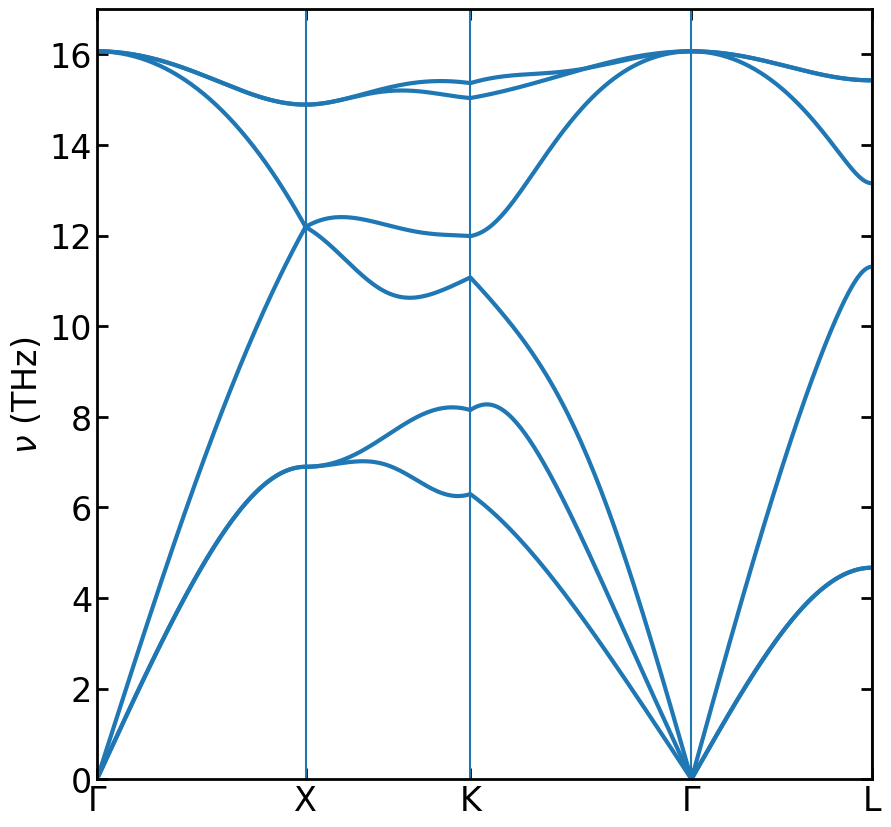

In [7]:
figure(figsize=(10,10))
set_fig_properties([gca()])
plot(linear_path, nu, color='C0',lw=3)
xlim([0, max(linear_path)])
vlines(sym_points, ymin=0, ymax=17)
gca().set_xticks(sym_points)
gca().set_xticklabels([r'$\Gamma$','X', 'K', r'$\Gamma$', 'L'])
ylim([0, 17])
ylabel(r'$\nu$ (THz)')
show()

Phonon dispersion of silicon crystal described by the mini-Tersoff potential.

- The above figure shows the phonon dispersion of silicon crystal described by the mini-Tersoff potential [[Fan 2020]](https://doi.org/10.1088/1361-648X/ab5c5f)

## References
[Fan 2020] Zheyong Fan, Yanzhou Wang, Xiaokun Gu, Ping Qian, Yanjing Su, and Tapio Ala-Nissila, [A minimal Tersoff potential for diamond silicon with improved descriptions of elastic and phonon transport properties](https://doi.org/10.1088/1361-648X/ab5c5f), J. Phys.: Condens. Matter **32** 135901 (2020).